# Wykrywanie naczyń dna oka — wymagania na 5.0 (sieć U-Net), zbiór **HRF**

Najwyższy poziom: zamiast ręcznych cech (4.0) używamy **głębokiej sieci U-Net**, która
sama uczy się cech z **całych obrazów**. Implementacja w PyTorch (akceleracja Apple MPS):
[`src/unet.py`](../src/unet.py).

- Sieć: U-Net (enkoder–dekoder ze skip-połączeniami), wejście RGB, wyjście = mapa
  prawdopodobieństwa „naczynie".
- Uczenie na **całych obrazach** HRF (scale=0.2, dopełnione do 480×704), augmentacja
  (odbicia), strata **BCE + Dice** liczona tylko w polu widzenia (FOV).
- Test na tych samych 6 obrazach **hold-out** co 3.0 i 4.0 — uczciwe porównanie.

In [1]:
import sys, time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import data, processing, features, unet, metrics, viz
from sklearn.ensemble import RandomForestClassifier

OUT_DIR = ROOT / "outputs" / "03_siec_5_hrf"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SCALE = 0.2
THRESHOLD = 0.10   # próg na prawdopodobieństwie z sieci (dobrany — patrz sekcja 3)
TEST_IDS = ["01_h", "02_h", "01_dr", "02_dr", "01_g", "02_g"]
TRAIN_IDS = [i for i in data.list_hrf_ids() if i not in TEST_IDS]
print("device:", unet.get_device())
print(f"uczące={len(TRAIN_IDS)}  testowe(hold-out)={TEST_IDS}")

device: mps
uczące=39  testowe(hold-out)=['01_h', '02_h', '01_dr', '02_dr', '01_g', '02_g']


## 1. Dane

Sieć dostaje cały obraz RGB i uczy się odtwarzać maskę naczyń. Pokazujemy przykład.

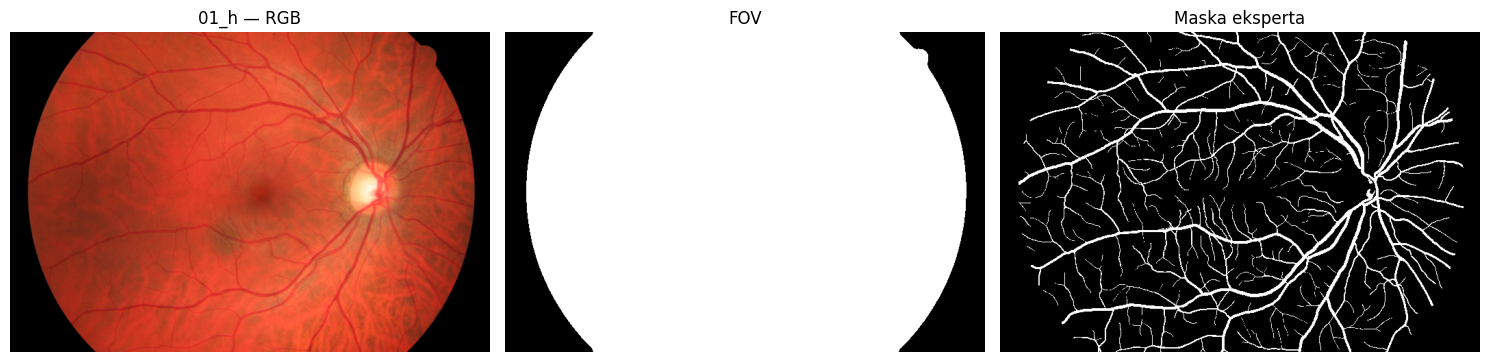

In [2]:
demo = TEST_IDS[0]
rgb = data.load_hrf_image(demo, SCALE); fov = data.load_hrf_fov(demo, SCALE); gt = data.load_hrf_label(demo, SCALE)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
ax[0].imshow(rgb); ax[0].set_title(f"{demo} — RGB")
ax[1].imshow(fov, cmap="gray"); ax[1].set_title("FOV")
ax[2].imshow(gt, cmap="gray"); ax[2].set_title("Maska eksperta")
for a in ax: a.axis("off")
fig.tight_layout(); plt.show()

## 2. Uczenie sieci U-Net

Trening na 39 obrazach (≈5 min na MPS). Strata maleje — sieć uczy się naczyń.

In [ ]:
t = time.time()
model = unet.train_unet(TRAIN_IDS, scale=SCALE, epochs=70, seed=0, verbose=True)
print(f"Trening zakończony w {time.time()-t:.0f}s")

  epoka   1/70  strata=1.3220
  epoka  10/70  strata=0.7483


## 3. Dobór progu decyzyjnego

Sieć zwraca prawdopodobieństwo (0–1). Domyślny próg 0,5 daje wysoką swoistość, ale za
niską **czułość** (gubi cienkie naczynia). Obniżając próg, łapiemy więcej naczyń. Próg
dobieramy pod najlepszą **średnią geometryczną** (miara dla danych niezrównoważonych).

In [ ]:
te = [(i, data.load_hrf_image(i, SCALE), data.load_hrf_fov(i, SCALE), data.load_hrf_label(i, SCALE)) for i in TEST_IDS]
rows = []
for thr in [0.10, 0.15, 0.20, 0.25, 0.30, 0.50]:
    gms = [metrics.evaluate(unet.predict_mask(model, rgb, fov, threshold=thr), gt, fov).geometric_mean
           for _, rgb, fov, gt in te]
    rows.append({"próg": thr, "śr. geom.": np.mean(gms)})
display(pd.DataFrame(rows).set_index("próg").round(3))
print("Używamy progu:", THRESHOLD)

## 4. Porównanie metod na zbiorze testowym (hold-out)

Liczymy maski trzema metodami — **3.0 (Frangi)**, **Random Forest (4.0)**, **U-Net (5.0)**
— na tych samych obrazach i porównujemy z maską eksperta.

In [ ]:
# RF (4.0) — szybki trening na tych samych obrazach co w notebooku 2
RF_TRAIN = ["03_h", "04_h", "05_h", "03_dr", "04_dr", "03_g", "04_g"]
Xtr = [data.load_hrf_image(i, SCALE) for i in RF_TRAIN]
Ftr = [data.load_hrf_fov(i, SCALE) for i in RF_TRAIN]
Gtr = [data.load_hrf_label(i, SCALE) for i in RF_TRAIN]
X, y, _ = features.build_dataset(Xtr, Ftr, Gtr, n_per_class_per_image=8000)
rf = RandomForestClassifier(n_estimators=120, n_jobs=-1, random_state=0).fit(X, y)

rows_30, rows_rf, rows_un = [], [], []
masks_un = {}
for i, rgb, fov, gt in te:
    m30, _ = processing.segment_vessels(rgb, fov=fov, low=0.005, high=0.02, min_size=100)
    mrf = features.predict_mask(rf, rgb, fov)
    mun = unet.predict_mask(model, rgb, fov, threshold=THRESHOLD)
    masks_un[i] = (rgb, fov, gt, mun)
    rows_30.append({"obraz": i, **metrics.evaluate(m30, gt, fov).as_dict()})
    rows_rf.append({"obraz": i, **metrics.evaluate(mrf, gt, fov).as_dict()})
    rows_un.append({"obraz": i, **metrics.evaluate(mun, gt, fov).as_dict()})
print("Gotowe.")

In [ ]:
def mean_row(rows, label):
    s = pd.DataFrame(rows).set_index("obraz")[["accuracy","sensitivity","specificity","geometric_mean"]].mean()
    s.name = label; return s
cmp = pd.DataFrame([mean_row(rows_30,"3.0 (Frangi)"), mean_row(rows_rf,"4.0 (Random Forest)"), mean_row(rows_un,"5.0 (U-Net)")])
cmp = cmp.rename(columns={"accuracy":"trafność","sensitivity":"czułość","specificity":"swoistość","geometric_mean":"śr. geom."})
display(cmp.round(3))
print("Najlepsza średnia geometryczna:", cmp["śr. geom."].idxmax())

### Metryki U-Net per obraz

In [ ]:
df_un = pd.DataFrame(rows_un).set_index("obraz").rename(columns={
    "tn":"TN","fp":"FP","fn":"FN","tp":"TP","accuracy":"trafność","sensitivity":"czułość",
    "specificity":"swoistość","arithmetic_mean":"śr. arytm.","geometric_mean":"śr. geom."})
df_un.loc["ŚREDNIA"] = df_un.mean(numeric_only=True)
df_un.to_csv(OUT_DIR / "metryki_unet.csv")
fc = ["trafność","czułość","swoistość","śr. arytm.","śr. geom."]
display(df_un.round({c:3 for c in fc}))

## 5. Wizualizacja (U-Net)

**obraz | maska eksperta | U-Net | mapa błędów** (zielony=trafione, czerwony=fałszywy
alarm, niebieski=przeoczone).

In [ ]:
for i in TEST_IDS:
    rgb, fov, gt, mun = masks_un[i]
    fig = viz.comparison_panel(rgb, gt, mun, fov, title=f"{i} — U-Net")
    fig.savefig(OUT_DIR / f"{i}_unet_panel.png", dpi=90, bbox_inches="tight")
    plt.imsave(OUT_DIR / f"{i}_unet_mask.png", mun, cmap="gray")
    plt.show()

## 6. Podsumowanie

- **U-Net (5.0) osiąga najlepszą średnią geometryczną** spośród wszystkich metod —
  bije zarówno przetwarzanie obrazu (3.0), jak i Random Forest (4.0).
- Sieć sama uczy się cech z całych obrazów, więc lepiej radzi sobie z trudnymi
  fragmentami (cienkie naczynia, okolice zmian chorobowych) niż ręcznie zaprojektowane
  cechy.
- Kosztem jest dłuższy czas uczenia i potrzeba akceleracji (MPS/GPU) oraz większej
  liczby obrazów uczących.
- Test na obrazach hold-out (innych niż uczące) potwierdza, że wynik uogólnia się na
  nowe dane.